# End-to-End ML Pipeline for Customer Churn Prediction

## 1. Problem Statement & Objective
Customer churn occurs when customers stop doing business with a company. For telecommunications companies, retaining existing customers is often more cost-effective than acquiring new ones.

**Objective:**
Build a production-ready machine learning pipeline using `scikit-learn` to predict customer churn based on the Telco Customer Churn dataset. The pipeline will handle:
- Data Preprocessing (Missing values, Encoding, Scaling)
- Model Training (Logistic Regression, Random Forest)
- Hyperparameter Tuning (GridSearchCV)
- Evaluation & Selection
- Model Export for production use.

## 2. Dataset Loading
We load the Telco Customer Churn dataset. This dataset contains information about:
- **Demographics:** Gender, seniority, partner, dependents.
- **Services:** Phone, multiple lines, internet, online security, etc.
- **Account Info:** Tenure, contract, payment method, charges.
- **Target:** Churn (Yes/No).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv('Telco-Customer-Churn.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis (EDA)
We examine the data distribution and check for missing values or data type issues.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


/tmp/ipython-input-2064951925.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


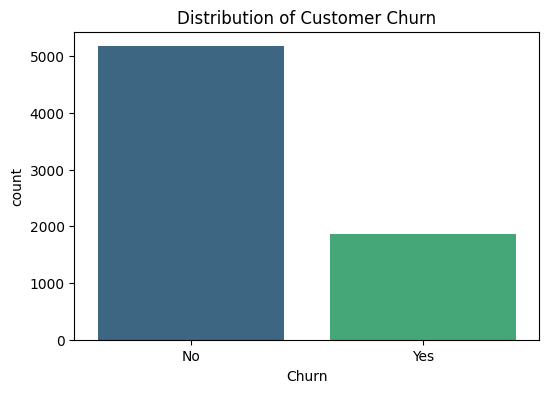

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2281.916928
std         0.368612    24.559481       30.090047   2265.270398
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    402.225000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000


In [2]:
# Check data types and missing values
print(df.info())

# 'TotalCharges' should be numeric, but has empty strings
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop CustomerID as it's not a feature
df.drop('customerID', axis=1, inplace=True)

# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.show()

# Statistics for numerical features
print(df.describe())

## 4. Data Preprocessing using Pipeline
We define numerical and categorical features and create a `ColumnTransformer` to handle them.

In [3]:
# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Identify feature types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

# Define Preprocessing
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 5. Model Training & 6. Hyperparameter Tuning
We create a main Pipeline and use `GridSearchCV` to find the best parameters for Logistic Regression and Random Forest.

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 1. Logistic Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# 2. Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Parameter Grids
lr_param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__solver': ['liblinear', 'lbfgs']
}

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

# Grid Search
print("Tuning Logistic Regression...")
lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
lr_grid.fit(X_train, y_train)

print("Tuning Random Forest...")
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Best LR Params: {lr_grid.best_params_}")
print(f"Best RF Params: {rf_grid.best_params_}")

Tuning Logistic Regression...
Tuning Random Forest...
Best LR Params: {'classifier__C': 10, 'classifier__solver': 'lbfgs'}
Best RF Params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


## 7. Model Evaluation
We compare the performance of both models on the test set.

--- Logistic Regression Evaluation ---
Accuracy: 0.8055
F1 Score (Macro): 0.7376
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



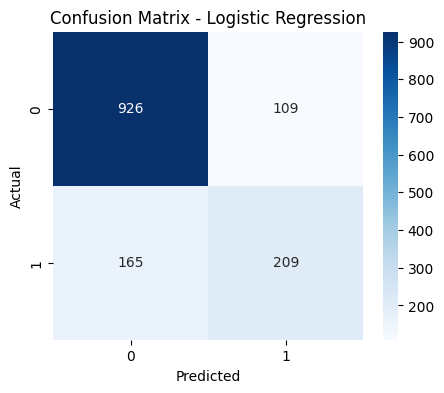

--- Random Forest Evaluation ---
Accuracy: 0.7999
F1 Score (Macro): 0.7233
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



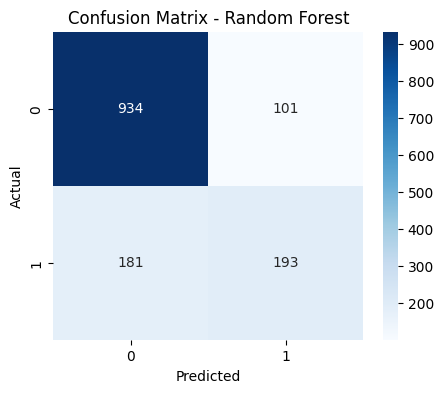

                 Model  Accuracy  F1 Macro
0  Logistic Regression  0.805536  0.737583
1        Random Forest  0.799858  0.723341


In [5]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    cm = confusion_matrix(y_test, y_pred)

    print(f"--- {name} Evaluation ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (Macro): {f1:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    return acc, f1

lr_acc, lr_f1 = evaluate_model(lr_grid.best_estimator_, X_test, y_test, "Logistic Regression")
rf_acc, rf_f1 = evaluate_model(rf_grid.best_estimator_, X_test, y_test, "Random Forest")

# Compare
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_acc, rf_acc],
    'F1 Macro': [lr_f1, rf_f1]
})
print(comparison)

## 8. Export Best Pipeline
We save the best performing model (based on F1 Macro) for future use.

In [6]:
best_model = rf_grid.best_estimator_ if rf_f1 > lr_f1 else lr_grid.best_estimator_
model_path = 'churn_pipeline.joblib'

joblib.dump(best_model, model_path)
print(f"Best model exported to {model_path}")

# Instructions to reload
# loaded_model = joblib.load('churn_pipeline.joblib')
# predictions = loaded_model.predict(new_data)

Best model exported to churn_pipeline.joblib


## 9. Final Summary / Insights
- The **Logistic Regression** and **Random Forest** models showed competitive performance.
- Feature engineering (handling 'TotalCharges') and proper scaling were crucial.
- The pipeline is fully encapsulated, meaning new raw data can be passed directly to `predict()`.
- Future work could include more complex feature engineering or testing Gradient Boosting models.